## Imports

In [1]:
from Functions import *
import matplotlib
import colormaps as cmaps

## Automatic Roll Identification and Cross Section Creation

In [2]:
sample = xr.open_dataset("./SampleData/ncf_20240913_003847.nc")
vad = xr.open_dataset("./SampleData/KNQA_2024-09-13 0032_VAD_10km.nc")

# We are choosing an analysis height of z = 0.35 km
z = 0.35

Order of Operations:
1. Create a strong filtered residual velocity field --> Emphasizes more roll-like features (subsetFilter)
2. Find the dominant frequency of the residual velocity field using FFT --> Used in Gabor Filter (find_frequency)
3. Use the Gabor filter to find potential roll-like structures (GaborMask)
4. Group potential roll like features together into clusters (feature_DBSCAN)
5. Create cross sections according to feature cluster orientation (makeCrossSections)
6. Label and identify roll like features in cross sections using gradient_label (in plotting section, gradient_label)
7. Calculate wavelengths and depth according to feature centroid (in plotting section, calculate_half_wavelength_profiles)

In [3]:
subset_filled, mean_vad_direction, ref_filled, strong_filtered = subsetFilter(sample, vad, z=z) # 1
dom_freq, dom_lambda, bin_centers, radial_power = find_frequency(sample, z=z) # 2
labeled_arms, filt_real, input_field, stdev, clean_mask = GaborMask(strong_filtered, theta=mean_vad_direction, frequency=dom_freq, gaussian_sigma=dom_lambda/2, min_object_size=15) # 3
df_features = feature_DBSCAN(sample, labeled_arms, z=z, eps=1) # 4

In [4]:
cross_sections = makeCrossSections(sample, z, df_features, mean_vad_direction) # 5

## Plotting the Results

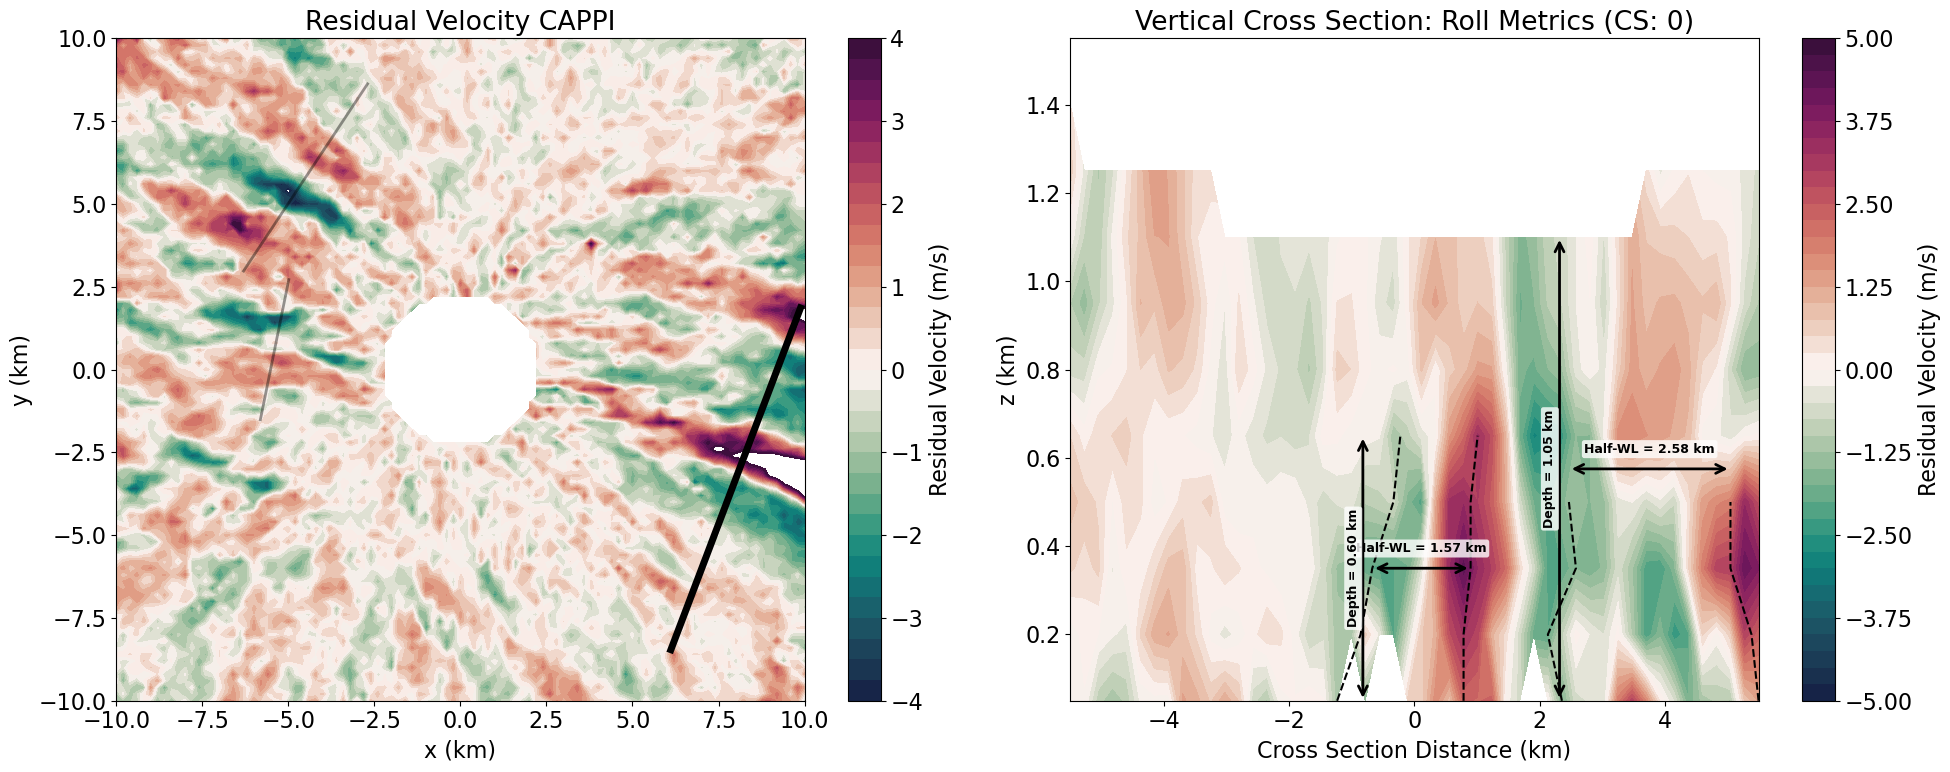

In [5]:
matplotlib.rcParams.update({'font.size': 16})

# Get the single cross-section you want to plot
cs_idx = 0  
cs = cross_sections[cs_idx]

r_vel_cs = cs['profile']
distances_cs = cs['s']

# Extract coordinates and the planview CAPPI field slice
X = sample.x0
Y = sample.y0
heights_cs = sample.z0.values
field = sample.isel(time=0).sel(z0=z).r_vel

# Run the processing pipeline in the correct sequence
# AUTOMATIC IDENTIFICATION OF ROLLS
try:
    # Get the masked array and object matches from gradient labeling
    r_vel_masked, df_matches = gradient_label(
        r_vel=r_vel_cs, 
        heights=heights_cs, 
        distances=distances_cs
    ) # 6
    
    # Calculate structural profiles using the matching dataframe
    profiles_calc = None
    if df_matches is not None and isinstance(df_matches, pd.DataFrame) and not df_matches.empty:
        profiles_calc = calculate_half_wavelength_profiles(
            r_vel_masked=r_vel_masked, 
            heights=heights_cs, 
            distances=distances_cs, 
            df_matches=df_matches
        ) # 7
except Exception as e:
    print(f"Feature extraction failed on CS {cs_idx}: {e}")
    profiles_calc = None

# Plotting Phase
fig, axes = plt.subplots(1, 2, figsize=(20, 8))


# Residual Velocity CAPPI with Track Overlays
cf_cappi = axes[0].contourf(X, Y, field, levels=np.arange(-4, 4.25, 0.25), cmap=cmaps.curl)

if cross_sections:
    for target_cs in cross_sections:
        is_active = (target_cs['gid'] == cs['gid'])
        lw = 5 if is_active else 2
        alpha = 1.0 if is_active else 0.4
        axes[0].plot(target_cs["x"], target_cs["y"], color="k", linewidth=lw, alpha=alpha)
        
axes[0].set_title("Residual Velocity CAPPI")
axes[0].set_xlabel("x (km)")
axes[0].set_ylabel("y (km)")
fig.colorbar(cf_cappi, ax=axes[0], label="Residual Velocity (m/s)")

# Vertical Cross-Section with Geometric Metrics
cf_cs = axes[1].contourf(distances_cs, heights_cs, r_vel_cs, levels=np.arange(-5, 5.25, 0.25), cmap=cmaps.curl)

if profiles_calc is not None:
    for pair_name, df_pair in profiles_calc.items():
        if df_pair is None or df_pair.empty: 
            continue
        
        # Plot boundary centerlines
        axes[1].plot(df_pair['Obj_A_Center'], df_pair['Height_km'], color='black', lw=1.5, ls='--')
        axes[1].plot(df_pair['Obj_B_Center'], df_pair['Height_km'], color='black', lw=1.5, ls='--')

        # Extract structural boundaries for dimension annotations
        top_h = df_pair['Top_Height_km'].iloc[0]
        bot_h = df_pair['Bottom_Height_km'].iloc[0]
        mid_h = (top_h + bot_h) / 2.0
        depth = top_h - bot_h
        idx = (df_pair['Height_km'] - mid_h).abs().idxmin()

        # Wavelength Annotation (Horizontal arrows + boxed text)
        axes[1].annotate('', xy=(df_pair.loc[idx, 'Obj_A_Center'], mid_h), 
                         xytext=(df_pair.loc[idx, 'Obj_B_Center'], mid_h), 
                         arrowprops=dict(arrowstyle='<->', color='black', lw=2))
        
        axes[1].text((df_pair.loc[idx, 'Obj_A_Center'] + df_pair.loc[idx, 'Obj_B_Center']) / 2, mid_h + 0.03, 
                     f"Half-WL = {df_pair.loc[idx, 'Half_Wavelength_km']:.2f} km", 
                     ha='center', va='bottom', color='black', fontsize=9, fontweight='bold', 
                     bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, ec='none'))
        
        # Depth Annotation (Vertical arrows + rotating boxed text)
        left_x = min(df_pair.loc[idx, 'Obj_A_Center'], df_pair.loc[idx, 'Obj_B_Center'])
        axes[1].annotate('', xy=(left_x - 0.15, bot_h), 
                         xytext=(left_x - 0.15, top_h), 
                         arrowprops=dict(arrowstyle='<->', color='black', lw=2))
        
        axes[1].text(left_x - 0.20, mid_h, f"Depth = {depth:.2f} km", 
                     ha='right', va='center', color='black', fontsize=9, fontweight='bold', rotation=90, 
                     bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, ec='none'))

    axes[1].set_title(f"Vertical Cross Section: Roll Metrics (CS: {cs_idx})")
else:
    axes[1].set_title(f"Vertical Cross Section [Extraction Skipped/No Rolls] (CS: {cs_idx})")
    
axes[1].set_xlabel('Cross Section Distance (km)')
axes[1].set_ylabel("z (km)")
fig.colorbar(cf_cs, ax=axes[1], label='Residual Velocity (m/s)')

plt.tight_layout()
plt.show()